In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu từ file csv
df = pd.read_csv('creditcard.csv')

# 2. Chuẩn hóa 2 biến Amount (Số tiền) và Time (Thời gian)
rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Xóa 2 cột cũ và đưa 2 cột mới lên đầu cho gọn
df.drop(['Time','Amount'], axis=1, inplace=True)
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# 3. Tách biến đặc trưng (X) và nhãn (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 4. Chia tập Train/Test (Tỷ lệ 80/20, giữ nguyên tỷ lệ gian lận bằng stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước tập Huấn luyện (Train): {X_train.shape}")
print(f"Kích thước tập Kiểm tra (Test): {X_test.shape}")

Kích thước tập Huấn luyện (Train): (227845, 30)
Kích thước tập Kiểm tra (Test): (56962, 30)


In [2]:
from imblearn.over_sampling import SMOTE

# chạy thuật toán SMOTE để tạo dữ liệu cân bằng cho tập Train..."
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print(f"Số lượng giao dịch ban đầu (Train): {len(y_train)}")
print(f"Số lượng giao dịch sau SMOTE (Train): {len(y_train_smote)}")

Số lượng giao dịch ban đầu (Train): 227845
Số lượng giao dịch sau SMOTE (Train): 454902


In [3]:
from sklearn.linear_model import LogisticRegression

# huấn luyện Logistic Regression (Mô hình 1)

# max_iter=1000 giúp mô hình chạy mượt mà không báo lỗi
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_smote, y_train_smote)

# Cho mô hình làm bài thi trên tập Test
y_pred_log = log_reg.predict(X_test)
print("Huấn luyện và dự đoán thành công!")

Huấn luyện và dự đoán thành công!


BÁO CÁO PHÂN LOẠI - LOGISTIC REGRESSION:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



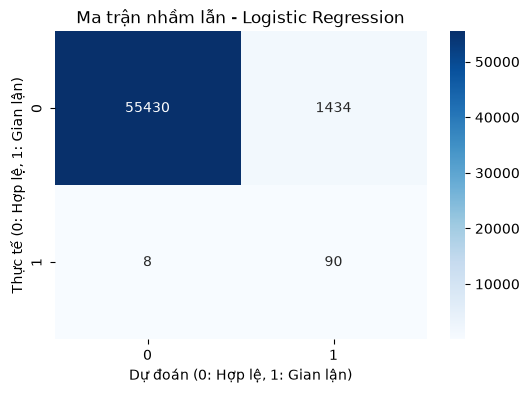

In [4]:
from sklearn.metrics import classification_report, confusion_matrix

# In bảng báo cáo
print("BÁO CÁO PHÂN LOẠI - LOGISTIC REGRESSION:")
print(classification_report(y_test, y_pred_log))

# Vẽ Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Ma trận nhầm lẫn - Logistic Regression")
plt.ylabel('Thực tế (0: Hợp lệ, 1: Gian lận)')
plt.xlabel('Dự đoán (0: Hợp lệ, 1: Gian lận)')
plt.show()

Huấn luyện Random Forest thành công!

BÁO CÁO PHÂN LOẠI - RANDOM FOREST:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



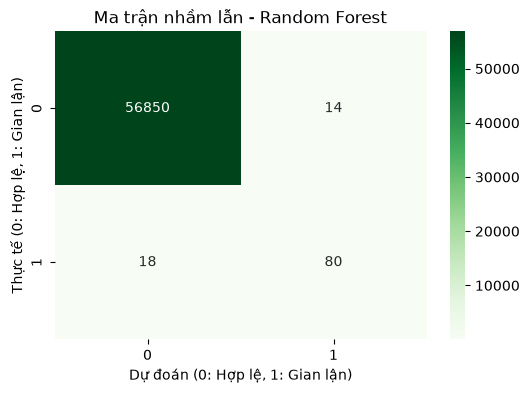

In [5]:
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo Random Forest với n_jobs=-1 để tận dụng tối đa sức mạnh của CPU
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Cho mô hình học trên tập dữ liệu đã SMOTE
rf_model.fit(X_train_smote, y_train_smote)

# Dự đoán trên tập Test
y_pred_rf = rf_model.predict(X_test)
print("Huấn luyện Random Forest thành công!")

# BÁO CÁO VÀ VẼ BIỂU ĐỒ
print("\nBÁO CÁO PHÂN LOẠI - RANDOM FOREST:")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens") # Đổi sang màu Xanh lá cho dễ phân biệt
plt.title("Ma trận nhầm lẫn - Random Forest")
plt.ylabel('Thực tế (0: Hợp lệ, 1: Gian lận)')
plt.xlabel('Dự đoán (0: Hợp lệ, 1: Gian lận)')
plt.show()

Trọng số phạt áp dụng: 577.29
Huấn luyện XGBoost thành công trong nháy mắt!

BÁO CÁO PHÂN LOẠI - XGBOOST:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



c:\Users\PCMSI\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\core.py:569: UserWarning: [20:54:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


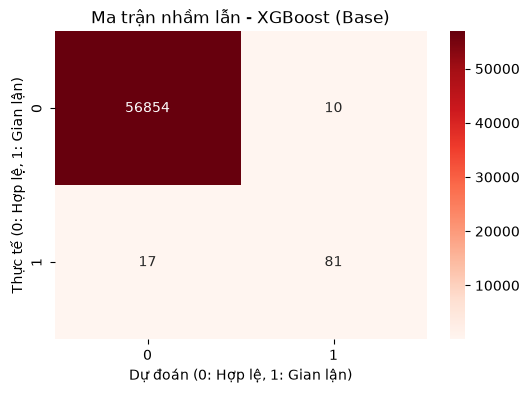

In [6]:
import xgboost as xgb

# Tính toán trọng số phạt (scale_pos_weight)...
# Công thức: Tổng số ca Hợp lệ (Class 0) / Tổng số ca Gian lận (Class 1)
weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Trọng số phạt áp dụng: {weight:.2f}")

# Khởi tạo mô hình
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=weight, # Tích hợp xử lý mất cân bằng ngay bên trong thuật toán
    tree_method='hist',      # Thuật toán dựng cây tối ưu
    device='cuda',
    random_state=42
)

# Chú ý: Ta dùng X_train, y_train GỐC (không có chữ smote)
xgb_model.fit(X_train, y_train)

# Dự đoán
y_pred_xgb = xgb_model.predict(X_test)
print("Huấn luyện XGBoost thành công trong nháy mắt!")

# BÁO CÁO VÀ VẼ BIỂU ĐỒ
print("\nBÁO CÁO PHÂN LOẠI - XGBOOST:")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds") # Đổi sang màu Đỏ
plt.title("Ma trận nhầm lẫn - XGBoost (Base)")
plt.ylabel('Thực tế (0: Hợp lệ, 1: Gian lận)')
plt.xlabel('Dự đoán (0: Hợp lệ, 1: Gian lận)')
plt.show()

Fitting 3 folds for each of 12 candidates, totalling 36 fits

[THÀNH CÔNG] Bộ tham số tối ưu nhất tìm được là:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

BÁO CÁO PHÂN LOẠI - TUNED XGBOOST:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



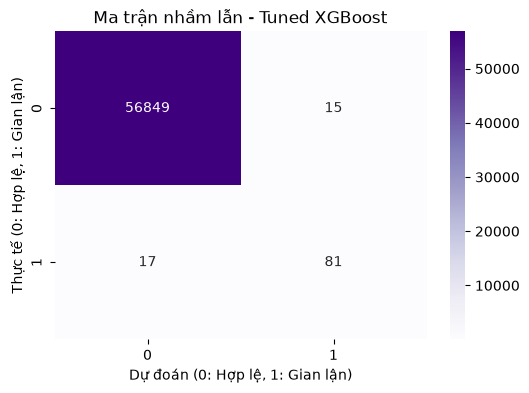

In [7]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# thiết lập không gian tham số cho XGBoost
weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 1. Định nghĩa mô hình cơ sở với GPU
xgb_estimator = xgb.XGBClassifier(
    scale_pos_weight=weight,
    tree_method='hist',
    device='cuda',
    random_state=42
)

# 2. Tạo không gian tham số để máy tự dò tìm
param_grid = {
    'max_depth': [3, 5, 7],           # Độ sâu của cây: Cây càng nông càng tránh học vẹt
    'learning_rate': [0.05, 0.1],     # Tốc độ học: Hội tụ chậm
    'n_estimators': [100, 200]        # Số lượng cây quyết định
}

# 3. Khởi tạo lưới tìm kiếm (Dùng AUPRC - average_precision làm tiêu chí chấm điểm)
grid_search = GridSearchCV(
    estimator=xgb_estimator, 
    param_grid=param_grid, 
    cv=3,                            # Chia dữ liệu làm 3 phần để test chéo
    scoring='average_precision',     # Tối ưu hóa đường cong PR (rất tốt cho dữ liệu lệch)
    verbose=1                        # In tiến trình ra màn hình
)

# tiến hành GridSearchCV... Máy sẽ huấn luyện tổng cộng 36 mô hình nhỏ
grid_search.fit(X_train, y_train)

# In ra bộ tham số tốt nhất tìm được
print(f"\n[THÀNH CÔNG] Bộ tham số tối ưu nhất tìm được là:\n{grid_search.best_params_}")

# 4. Dùng mô hình để dự đoán
best_xgb_model = grid_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test)

# 5. Xuất Báo cáo và Vẽ Ma trận nhầm lẫn
print("\nBÁO CÁO PHÂN LOẠI - TUNED XGBOOST:")
print(classification_report(y_test, y_pred_tuned))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Purples") # Chuyển sang màu Tím
plt.title("Ma trận nhầm lẫn - Tuned XGBoost")
plt.ylabel('Thực tế (0: Hợp lệ, 1: Gian lận)')
plt.xlabel('Dự đoán (0: Hợp lệ, 1: Gian lận)')
plt.show()